# Illumination for Arwen beam per beam

In [ ]:
import numpy as np
import scipy as sp
import pandas as pd
from helpers import rwbeams, rwhist

import matplotlib.pyplot as plt

## Data Extraction

In [21]:
df_omega = rwbeams.read_beams("omega60_master_config.xlsx")

# Extraction des valeurs sous forme de tableaux numpy
thetas = df_omega['LAT_rad'].values
energies = df_omega['energy'].values

# Vérification du nombre de faisceaux
num_beams = len(df_omega)

## Parameter definition

In [22]:
BEAM_RADIUS = 0.14       # Rayon du faisceau (mètres)
TARGET_RADIUS = 0.001    # Rayon de la cible (mètres)
CHAMBER_RADIUS = 1.65    # Rayon de la chambre / distance focale (mètres)


my_defocus = 0.05 * 1e-3 

# Paramètres de simulation
R_injection = 1.0        # Sphère de départ des rayons (mètres)

## We loop on all the rays to have their data

In [23]:
def generate_rays(thetas, energies, R_injection, defocus):
    # Calcul vectoriel des positions de départ
    r_start = R_injection * np.sin(thetas)
    z_start = R_injection * np.cos(thetas)
    
    # Calcul vectoriel des points focaux avec le defocus
    r_target = -defocus * np.sin(thetas)
    z_target = -defocus * np.cos(thetas)
    
    # Calcul vectoriel des directions
    dir_r = r_target - r_start
    dir_z = z_target - z_start
    
    # Normalisation vectorielle
    norm = np.sqrt(dir_r**2 + dir_z**2)
    dir_r = dir_r / norm
    dir_z = dir_z / norm
    
    # Structuration des données en tableaux 2D (colonnes R et Z)
    positions = np.column_stack((r_start, z_start))
    directions = np.column_stack((dir_r, dir_z))
    
    return positions, directions, energies

# Appel de la fonction avec les variables définies précédemment
all_rays_positions, all_rays_directions, all_rays_energies = generate_rays(
    thetas=thetas, 
    energies=energies, 
    R_injection=R_injection, 
    defocus=my_defocus
)



## Visualisation

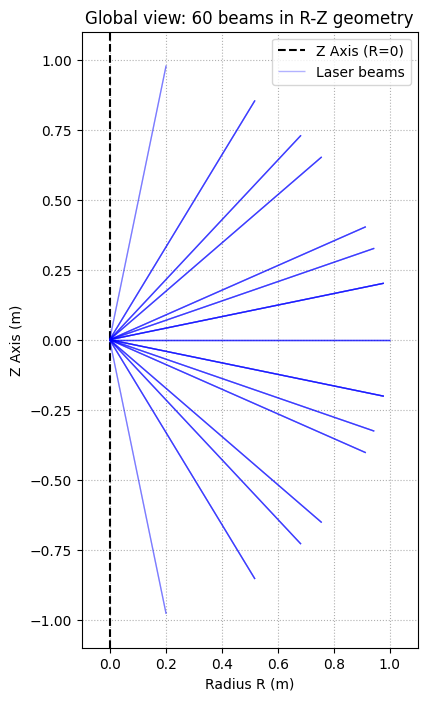

In [24]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

# Vectorized calculation of the end points for all rays
all_rays_ends = all_rays_positions + R_injection * all_rays_directions

# Data structuring for LineCollection: creating an array of segments
# Expected format: [[[r_start0, z_start0], [r_end0, z_end0]], ...]
segments = np.stack((all_rays_positions, all_rays_ends), axis=1)

fig, ax1 = plt.subplots(figsize=(8, 8))

# Drawing the axis of symmetry
ax1.axvline(x=0, color='black', linestyle='--', label='Z Axis (R=0)')

# Creating and adding the line collection
lc1 = LineCollection(segments, colors='blue', alpha=0.3, linewidths=1, label='Laser beams')
ax1.add_collection(lc1)

ax1.set_aspect('equal')
ax1.set_xlim(-0.1, 1.1)
ax1.set_ylim(-1.1, 1.1)
ax1.set_xlabel('Radius R (m)')
ax1.set_ylabel('Z Axis (m)')
ax1.set_title('Global view: 60 beams in R-Z geometry')
ax1.legend()
ax1.grid(True, linestyle=':')
plt.show()



## Creation of the txt file

In [25]:
file_name = 'rays_init.txt'

with open(file_name, 'w') as fd:
    for i in range(num_beams):
        r_start, z_start = all_rays_positions[i]
        dir_r, dir_z = all_rays_directions[i]
        energy = all_rays_energies[i]
        
        ligne = f"{r_start:15.7e} {z_start:15.7e} {dir_r:15.7e} {dir_z:15.7e} {energy:15.7e}\n"
        fd.write(ligne)